# 01 Network Log Anomaly Detection - LSTM Autoencoder

Train a dedicated **LSTM Autoencoder** for **network logs**.

In [1]:
import os, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
sys.path.append(os.path.abspath(".."))
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from src.preprocessing import (
    clean_column_names,
    basic_log_preprocess,
    add_text_length_features,
    fill_numeric,
    encode_categoricals,
    keep_or_create_columns,
    scale_features,
    create_sequences
)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

NORMAL_DATA_PATH = os.path.join(BASE_DIR, 'data/logs/network/normal_400k.csv')
ATTACK_DATA_PATH = os.path.join(BASE_DIR, 'data/logs/network/network_logs.csv')

MODEL_DIR = os.path.join(BASE_DIR, 'models', 'network_logs')
os.makedirs(MODEL_DIR, exist_ok=True)

## 1) Load dataset

In [2]:
df_normal = pd.read_csv(NORMAL_DATA_PATH)
df_attack = pd.read_csv(ATTACK_DATA_PATH)

print("Normal shape:", df_normal.shape)
print("Attack shape:", df_attack.shape)

df_normal.head()

C:\Users\Ysser-PC\AppData\Local\Temp\ipykernel_3892\3814317832.py:2: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attack = pd.read_csv(ATTACK_DATA_PATH)


Normal shape: (400000, 79)
Attack shape: (500000, 88)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,40474,7182757,1,5,6,30,6,6,6.0,0.000000,...,20,45201.000,0.000,45201,45201,7137556.0,0.00,7137556,7137556,BENIGN
1,28907,938509,1,5,6,30,6,6,6.0,0.000000,...,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN
2,0,119995732,123,0,0,0,0,0,0.0,0.000000,...,0,3753432.167,5183854.063,13200000,1,13100000.0,6507819.26,26300000,6484077,BENIGN
3,443,142954,10,6,553,3949,196,0,55.3,71.704719,...,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN
4,17541,2548725,1,6,6,36,6,6,6.0,0.000000,...,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN


In [3]:
print(df_normal.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

## 2) Configure columns
عدل القوائم دي حسب الداتا عندك.

In [4]:
timestamp_col = 'timestamp'
label_col = 'Label'

text_cols = ['src_ip', 'dst_ip', 'protocol', 'flag']

feature_candidates = [
    'flow_duration',
    'total_fwd_packets',
    'total_backward_packets',
    'total_length_of_fwd_packets',
    'total_length_of_bwd_packets',

    'fwd_packet_length_mean',
    'fwd_packet_length_std',
    'bwd_packet_length_mean',
    'bwd_packet_length_std',

    'flow_bytes/s',
    'flow_packets/s',

    'flow_iat_mean',
    'flow_iat_std',

    'packet_length_mean',
    'packet_length_std',

    'syn_flag_count',
    'ack_flag_count',
    'psh_flag_count',

    'average_packet_size',
    'avg_fwd_segment_size',
    'avg_bwd_segment_size',

    'subflow_fwd_packets',
    'subflow_bwd_packets',

    'init_win_bytes_forward',
    'init_win_bytes_backward',

    'active_mean',
    'active_std',
    'idle_mean',
    'idle_std'
]

sequence_length = 20
lstm_units = 64
latent_dim = 32
dropout_rate = 0.2
learning_rate = 1e-3
batch_size = 32
epochs = 10
threshold_percentile = 90
test_size = 0.2

## 3) Preprocess

In [ ]:

df_normal = clean_column_names(df_normal)
df_attack = clean_column_names(df_attack)


label_col = label_col.strip().lower().replace(" ", "_")


df_normal = basic_log_preprocess(df_normal, timestamp_col=timestamp_col)
df_attack = basic_log_preprocess(df_attack, timestamp_col=timestamp_col)


df_normal = add_text_length_features(df_normal, text_cols)
df_attack = add_text_length_features(df_attack, text_cols)


df_normal = fill_numeric(df_normal)
df_attack = fill_numeric(df_attack)


df_normal, encoders = encode_categoricals(df_normal)
df_attack, _ = encode_categoricals(df_attack)


if label_col not in df_normal.columns:
    df_normal[label_col] = 0

if label_col not in df_attack.columns:
    df_attack[label_col] = 1

feature_cols = [c for c in feature_candidates if c in df_normal.columns and c != label_col]

if not feature_cols:
    feature_cols = [
        c for c in df_normal.columns
        if c not in [timestamp_col, label_col] and pd.api.types.is_numeric_dtype(df_normal[c])
    ]


df_normal = keep_or_create_columns(df_normal, feature_cols + [label_col])
df_attack = keep_or_create_columns(df_attack, feature_cols + [label_col])
# 9) Replace inf / -inf with NaN
df_normal.replace([np.inf, -np.inf], np.nan, inplace=True)
df_attack.replace([np.inf, -np.inf], np.nan, inplace=True)


for col in feature_cols:
    if col in df_normal.columns:
        df_normal[col] = pd.to_numeric(df_normal[col], errors='coerce')
    if col in df_attack.columns:
        df_attack[col] = pd.to_numeric(df_attack[col], errors='coerce')


df_normal[feature_cols] = df_normal[feature_cols].fillna(df_normal[feature_cols].median())
df_attack[feature_cols] = df_attack[feature_cols].fillna(df_attack[feature_cols].median())


df_normal[feature_cols] = df_normal[feature_cols].clip(lower=-1e12, upper=1e12)
df_attack[feature_cols] = df_attack[feature_cols].clip(lower=-1e12, upper=1e12)

df_normal_train, df_normal_test = train_test_split(
    df_normal,
    test_size=test_size,
    random_state=42,
    shuffle=True
)


X_train_normal, scaler = scale_features(df_normal_train, feature_cols)
X_test_normal = scaler.transform(df_normal_test[feature_cols])
X_test_attack = scaler.transform(df_attack[feature_cols])


X_train_seq = create_sequences(X_train_normal, sequence_length=sequence_length)
X_test_normal_seq = create_sequences(X_test_normal, sequence_length=sequence_length)
X_test_attack_seq = create_sequences(X_test_attack, sequence_length=sequence_length)

print("Train normal seq shape:", X_train_seq.shape)
print("Test normal seq shape:", X_test_normal_seq.shape)
print("Test attack seq shape:", X_test_attack_seq.shape)
print("Number of features:", len(feature_cols))

Train normal seq shape: (319981, 20, 29)
Test normal seq shape: (79981, 20, 29)
Test attack seq shape: (499981, 20, 29)
Number of features: 29


## 4) Build model

In [6]:
n_features = X_train_seq.shape[2]

inputs = Input(shape=(sequence_length, n_features))
x = LSTM(lstm_units, activation='tanh', return_sequences=True)(inputs)
x = Dropout(dropout_rate)(x)
x = LSTM(latent_dim, activation='tanh', return_sequences=False)(x)
x = RepeatVector(sequence_length)(x)
x = LSTM(latent_dim, activation='tanh', return_sequences=True)(x)
x = Dropout(dropout_rate)(x)
x = LSTM(lstm_units, activation='tanh', return_sequences=True)(x)
outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 29)]          0         
                                                                 
 lstm (LSTM)                 (None, 20, 64)            24064     
                                                                 
 dropout (Dropout)           (None, 20, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 repeat_vector (RepeatVector  (None, 20, 32)           0         
 )                                                               
                                                                 
 lstm_2 (LSTM)               (None, 20, 32)            8320      
                                                             

## 5) Train

In [9]:
history = model.fit(
    X_train_seq,
    X_train_seq,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    shuffle=False 
)

Epoch 1/10
9000/9000 [==============================] - 941s 104ms/step - loss: 0.8525 - val_loss: 0.5502
Epoch 2/10
9000/9000 [==============================] - 490s 54ms/step - loss: 0.7660 - val_loss: 0.5180
Epoch 3/10
9000/9000 [==============================] - 527s 59ms/step - loss: 0.7365 - val_loss: 0.4924
Epoch 4/10
9000/9000 [==============================] - 557s 62ms/step - loss: 0.7183 - val_loss: 0.4862
Epoch 5/10
9000/9000 [==============================] - 462s 51ms/step - loss: 0.7050 - val_loss: 0.4599
Epoch 6/10
9000/9000 [==============================] - 561s 62ms/step - loss: 0.6835 - val_loss: 0.4393
Epoch 7/10
9000/9000 [==============================] - 414s 46ms/step - loss: 0.6633 - val_loss: 0.4277
Epoch 8/10
9000/9000 [==============================] - 861s 96ms/step - loss: 0.6696 - val_loss: 0.4281
Epoch 9/10
9000/9000 [==============================] - 1152s 128ms/step - loss: 0.6465 - val_loss: 0.4183
Epoch 10/10
9000/9000 [=============================

## 6) Compute threshold and save artifacts

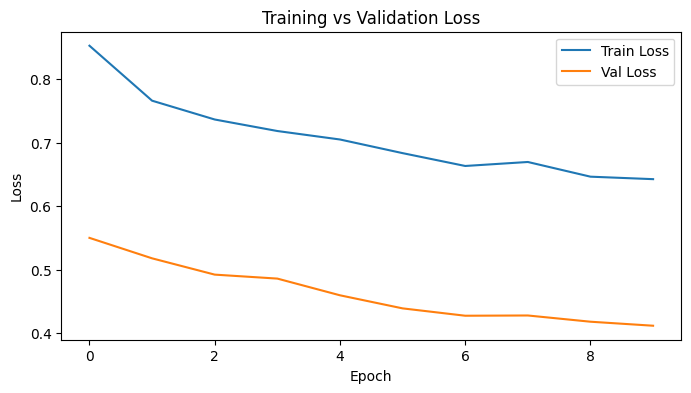

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Processed 64/319981
Processed 6464/319981
Processed 12864/319981
Processed 19264/319981
Processed 25664/319981
Processed 32064/319981
Processed 38464/319981
Processed 44864/319981
Processed 51264/319981
Processed 57664/319981
Processed 64064/319981
Processed 70464/319981
Processed 76864/319981
Processed 83264/319981
Processed 89664/319981
Processed 96064/319981
Processed 102464/319981
Processed 108864/319981
Processed 115264/319981
Processed 121664/319981
Processed 128064/319981
Processed 134464/319981
Processed 140864/319981
Processed 147264/319981
Processed 153664/319981
Processed 160064/319981
Processed 166464/319981
Processed 172864/319981
Processed 179264/319981
Processed 185664/319981
Processed 192064/319981
Processed 198464/319981
Processed 204864/319981
Processed 211264/319981
Processed 217664/319981
Processed 224064/319981
Processed 230464/319981
Processed 236864/319981
Processed 243264/319981
Processed 249664/319981
Processed 256064/319981
Processed 262464/319981
Processed 26

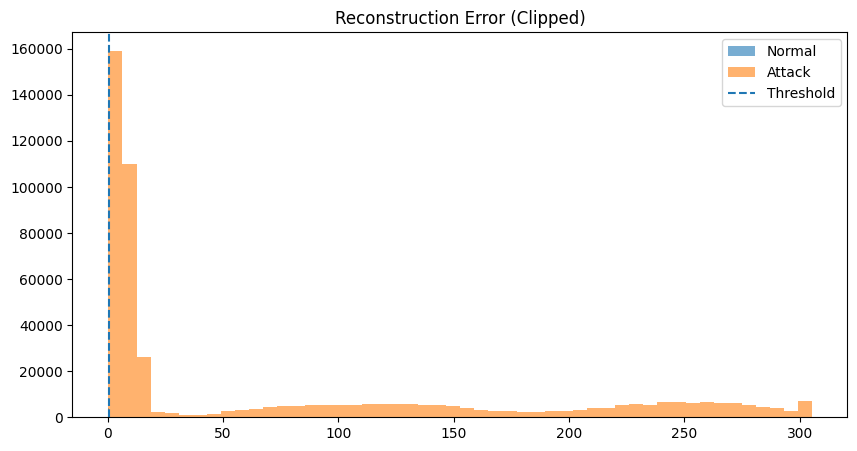

In [ ]:

def batched_reconstruction_mse(model, X, batch_size=64):
    all_errors = []
    n = len(X)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        X_batch = X[start:end]

        recon_batch = model.predict(X_batch, batch_size=batch_size, verbose=0)

        batch_error = np.mean((X_batch - recon_batch) ** 2, axis=(1, 2))
        all_errors.append(batch_error)

        if start % (batch_size * 100) == 0:
            print(f"Processed {end}/{n}")

    return np.concatenate(all_errors, axis=0)


mse_train = batched_reconstruction_mse(model, X_train_seq, batch_size=64)
mse_test_normal = batched_reconstruction_mse(model, X_test_normal_seq, batch_size=64)
mse_test_attack = batched_reconstruction_mse(model, X_test_attack_seq, batch_size=64)


threshold = float(np.percentile(mse_train, threshold_percentile))
print("Threshold:", threshold)


y_train_true = np.zeros(len(mse_train), dtype=int)
y_train_pred = (mse_train > threshold).astype(int)

y_test_true = np.concatenate([
    np.zeros(len(mse_test_normal), dtype=int),
    np.ones(len(mse_test_attack), dtype=int)
])

y_test_pred = np.concatenate([
    (mse_test_normal > threshold).astype(int),
    (mse_test_attack > threshold).astype(int)
])


print("===== TRAIN METRICS =====")
print("Accuracy :", accuracy_score(y_train_true, y_train_pred))
print("Precision:", precision_score(y_train_true, y_train_pred, zero_division=0))
print("Recall   :", recall_score(y_train_true, y_train_pred, zero_division=0))
print("F1-score :", f1_score(y_train_true, y_train_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_train_true, y_train_pred))

print("\n===== TEST METRICS =====")
print("Accuracy :", accuracy_score(y_test_true, y_test_pred))
print("Precision:", precision_score(y_test_true, y_test_pred, zero_division=0))
print("Recall   :", recall_score(y_test_true, y_test_pred, zero_division=0))
print("F1-score :", f1_score(y_test_true, y_test_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report:\n")
print(classification_report(y_test_true, y_test_pred, digits=4, zero_division=0))
print("Accuracy :", accuracy_score(y_train_true, y_train_pred))
print("Accuracy :", accuracy_score(y_test_true, y_test_pred))

plt.figure(figsize=(10,5))

plt.hist(np.clip(mse_test_normal, 0, np.percentile(mse_test_normal, 99)),
         bins=50, alpha=0.6, label='Normal')

plt.hist(np.clip(mse_test_attack, 0, np.percentile(mse_test_attack, 99)),
         bins=50, alpha=0.6, label='Attack')

plt.axvline(threshold, linestyle='--', label='Threshold')

plt.legend()
plt.title("Reconstruction Error (Clipped)")
plt.show()  



In [14]:
mse_train = batched_reconstruction_mse(model, X_train_seq, batch_size=64)
threshold = float(np.percentile(mse_train, threshold_percentile))
print("Threshold:", threshold)


model.save(os.path.join(MODEL_DIR, 'network_log_lstm_autoencoder.keras'))
model.save(os.path.join(MODEL_DIR, 'network_log_lstm_autoencoder.h5'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'network_log_scaler.joblib'))

config = {
    'source': 'network',
    'timestamp_col': timestamp_col,
    'label_col': label_col,
    'text_cols': text_cols,
    'feature_cols': feature_cols,
    'sequence_length': sequence_length,
    'lstm_units': lstm_units,
    'latent_dim': latent_dim,
    'dropout_rate': dropout_rate,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'epochs': epochs,
    'threshold_percentile': threshold_percentile,
    'threshold': threshold
}

with open(os.path.join(MODEL_DIR, 'network_log_model_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)

print("Saved to:", MODEL_DIR)

Processed 64/319981
Processed 6464/319981
Processed 12864/319981
Processed 19264/319981
Processed 25664/319981
Processed 32064/319981
Processed 38464/319981
Processed 44864/319981
Processed 51264/319981
Processed 57664/319981
Processed 64064/319981
Processed 70464/319981
Processed 76864/319981
Processed 83264/319981
Processed 89664/319981
Processed 96064/319981
Processed 102464/319981
Processed 108864/319981
Processed 115264/319981
Processed 121664/319981
Processed 128064/319981
Processed 134464/319981
Processed 140864/319981
Processed 147264/319981
Processed 153664/319981
Processed 160064/319981
Processed 166464/319981
Processed 172864/319981
Processed 179264/319981
Processed 185664/319981
Processed 192064/319981
Processed 198464/319981
Processed 204864/319981
Processed 211264/319981
Processed 217664/319981
Processed 224064/319981
Processed 230464/319981
Processed 236864/319981
Processed 243264/319981
Processed 249664/319981
Processed 256064/319981
Processed 262464/319981
Processed 26